<a href="https://colab.research.google.com/github/semmatoninn/CHE1148_MOFs_AtomicWizards/blob/main/EGNN_FullStructure_LocalHost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# =========================
# 1) INSTALL
# =========================

# Check runtime first: Runtime -> Change runtime type -> GPU
!nvidia-smi

import os
import sys
import subprocess

# Install PyG wheels matched to current Colab torch/cuda
import torch
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

TORCH = torch.__version__.split("+")[0]
CUDA = "cpu" if torch.version.cuda is None else "cu" + torch.version.cuda.replace(".", "")

# Official PyG wheel index pattern
!pip -qq install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html

!pip -qq install torch_geometric
!pip -qq install scipy pandas scikit-learn tqdm

print("Install done.")

Wed Apr  8 07:18:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# =========================
# 2) MOUNT DRIVE + IMPORTS
# =========================

from google.colab import drive
drive.mount('/content/drive')

import math
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool, radius_graph
from torch_geometric.utils import remove_self_loops

from scipy.stats import spearmanr, kendalltau
from sklearn.metrics import mean_absolute_error, mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Mounted at /content/drive
Device: cuda


In [5]:
# =========================
# 3) PATHS + CONFIG
# =========================

BASE_DIR = Path("/content/drive/MyDrive/MOF_Conf/processed_pyg")

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"
TEST_DIR  = BASE_DIR / "test"

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

# Training / graph settings
SEED = 42
BATCH_SIZE = 4          # safe starting point for ~300-atom graphs on T4
NUM_WORKERS = 2
LR = 1e-3
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 100
PATIENCE = 15

# Graph construction
CUTOFF = 5.0            # Angstrom, reasonable starting value
MAX_NEIGHBORS = 32      # helps memory / stability

# Model size
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 4
DROPOUT = 0.1

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

/content/drive/MyDrive/MOF_Conf/processed_pyg/train
/content/drive/MyDrive/MOF_Conf/processed_pyg/val
/content/drive/MyDrive/MOF_Conf/processed_pyg/test


In [7]:
# =========================
# 4) LOAD CHUNKED DATA
# =========================

def sorted_pt_files(folder: Path):
    return sorted(folder.glob("*.pt"))

train_files = sorted_pt_files(TRAIN_DIR)
val_files   = sorted_pt_files(VAL_DIR)
test_files  = sorted_pt_files(TEST_DIR)

print("Train files:", [f.name for f in train_files])
print("Val files:", [f.name for f in val_files])
print("Test files:", [f.name for f in test_files])

def load_chunk_list(pt_files):
    data_list = []
    for f in pt_files:
        print(f"Loading {f.name} ...")
        chunk = torch.load(f, map_location="cpu", weights_only=False)
        if isinstance(chunk, list):
            data_list.extend(chunk)
        else:
            raise TypeError(f"Unexpected object in {f}: {type(chunk)}")
    return data_list

train_data = load_chunk_list(train_files)
val_data   = load_chunk_list(val_files)
test_data  = load_chunk_list(test_files)

print(f"Train samples: {len(train_data)}")
print(f"Val samples:   {len(val_data)}")
print(f"Test samples:  {len(test_data)}")

sample = train_data[0]
print(sample)
print("Keys:", sample.keys())
print("z shape:", sample.z.shape)
print("pos shape:", sample.pos.shape)
print("y:", sample.y)
print("mof_name:", sample.mof_name)
print("config_name:", sample.config_name)

Train files: ['train_part_000.pt', 'train_part_001.pt', 'train_part_002.pt', 'train_part_003.pt']
Val files: ['val_part_000.pt']
Test files: ['test_part_000.pt']
Loading train_part_000.pt ...
Loading train_part_001.pt ...
Loading train_part_002.pt ...
Loading train_part_003.pt ...
Loading val_part_000.pt ...
Loading test_part_000.pt ...
Train samples: 1860
Val samples:   427
Test samples:  444
Data(y=[1], pos=[277, 3], z=[277], cell=[3, 3], pbc=[3], mof_name='ADOBEB_charged', config_name='ADOBEB_charged_w_CO2_1', num_atoms=277, split='train')
Keys: ['config_name', 'mof_name', 'split', 'cell', 'pbc', 'y', 'pos', 'z', 'num_atoms']
z shape: torch.Size([277])
pos shape: torch.Size([277, 3])
y: tensor([-0.1344])
mof_name: ADOBEB_charged
config_name: ADOBEB_charged_w_CO2_1


In [8]:
# 5) PRECOMPUTE EDGE_INDEX

def ensure_tensor_y(data):
    # make sure y is float tensor of shape [1]
    if not torch.is_tensor(data.y):
        data.y = torch.tensor([float(data.y)], dtype=torch.float)
    else:
        data.y = data.y.view(-1).float()
        if data.y.numel() == 1:
            pass
        else:
            data.y = data.y[:1]
    return data

def add_radius_edges(data, cutoff=CUTOFF, max_neighbors=MAX_NEIGHBORS):
    data = ensure_tensor_y(data)

    if hasattr(data, "edge_index") and data.edge_index is not None:
        return data

    pos = data.pos.float()
    edge_index = radius_graph(
        x=pos,
        r=cutoff,
        loop=False,
        max_num_neighbors=max_neighbors
    )
    edge_index, _ = remove_self_loops(edge_index)
    data.edge_index = edge_index
    return data

def preprocess_dataset(data_list, cutoff=CUTOFF, max_neighbors=MAX_NEIGHBORS):
    processed = []
    for data in tqdm(data_list):
        d = add_radius_edges(data, cutoff=cutoff, max_neighbors=max_neighbors)
        processed.append(d)
    return processed

train_data = preprocess_dataset(train_data)
val_data   = preprocess_dataset(val_data)
test_data  = preprocess_dataset(test_data)

# inspect one sample
s = train_data[0]
print("edge_index shape:", s.edge_index.shape)
print("num_nodes:", s.num_nodes)
print("num_edges:", s.edge_index.shape[1])

  0%|          | 0/1860 [00:00<?, ?it/s]

  0%|          | 0/427 [00:00<?, ?it/s]

  0%|          | 0/444 [00:00<?, ?it/s]

edge_index shape: torch.Size([2, 6345])
num_nodes: 277
num_edges: 6345


In [9]:
# 6) DATALOADERS

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

batch = next(iter(train_loader))
print(batch)
print("Batch num graphs:", batch.num_graphs)
print("Batch x nodes:", batch.z.shape)
print("Batch pos:", batch.pos.shape)
print("Batch y:", batch.y.shape)

DataBatch(y=[4], pos=[882, 3], z=[882], cell=[12, 3], pbc=[12], mof_name=[4], config_name=[4], num_atoms=[4], split=[4], edge_index=[2, 19692], batch=[882], ptr=[5])
Batch num graphs: 4
Batch x nodes: torch.Size([882])
Batch pos: torch.Size([882, 3])
Batch y: torch.Size([4])


In [18]:
# 7) MODEL - EGNN

import torch
import torch.nn as nn
from torch_geometric.nn import MessagePassing, global_mean_pool

class StableEGNNLayer(MessagePassing):
    def __init__(self, hidden_dim, dropout=0.0):
        super().__init__(aggr='add')
        self.hidden_dim = hidden_dim

        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU()
        )

        self.node_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, h, pos, edge_index):
        row, col = edge_index

        rel = pos[row] - pos[col]
        dist2 = (rel ** 2).sum(dim=-1, keepdim=True)
        dist2 = torch.clamp(dist2, min=0.0, max=1e4)

        m_ij = self.edge_mlp(torch.cat([h[row], h[col], dist2], dim=-1))
        m_ij = self.dropout(m_ij)

        agg = torch.zeros_like(h)
        agg.index_add_(0, row, m_ij)

        h_update = self.node_mlp(torch.cat([h, agg], dim=-1))
        h = self.norm(h + h_update)

        return h


class EnergyEGNN(nn.Module):
    def __init__(
        self,
        num_atom_types=120,
        embed_dim=128,
        hidden_dim=128,
        num_layers=4,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = nn.Embedding(num_atom_types, embed_dim)
        self.input_proj = nn.Linear(embed_dim, hidden_dim)

        self.layers = nn.ModuleList([
            StableEGNNLayer(hidden_dim=hidden_dim, dropout=dropout)
            for _ in range(num_layers)
        ])

        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        z = data.z.long()
        pos = data.pos.float()
        edge_index = data.edge_index
        batch = data.batch

        h = self.embedding(z)
        h = self.input_proj(h)

        for layer in self.layers:
            h = layer(h, pos, edge_index)

        g = global_mean_pool(h, batch)
        out = self.readout(g).view(-1)
        return out

In [19]:
# 8) INIT TRAINING OBJECTS

LR = 3e-4
WEIGHT_DECAY = 1e-5

model = EnergyEGNN(
    num_atom_types=120,   # enough to cover all atomic numbers in MOFs
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.7,
    patience=5
)

loss_fn = nn.MSELoss()   # you can switch to nn.L1Loss() if you want MAE training

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {num_params:,}")

Trainable params: 453,505


In [20]:

# 9) METRICS + AGGREGATION

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def safe_rank_corr(y_true, y_pred):
    sp = spearmanr(y_true, y_pred).correlation
    kt = kendalltau(y_true, y_pred).correlation
    return sp, kt

def aggregate_by_mof(records, agg="mean"):
    """
    records: list of dicts with keys:
      mof_name, y_true, y_pred
    returns per-MOF arrays
    """
    by_mof = defaultdict(lambda: {"y_true": [], "y_pred": []})

    for r in records:
        by_mof[r["mof_name"]]["y_true"].append(float(r["y_true"]))
        by_mof[r["mof_name"]]["y_pred"].append(float(r["y_pred"]))

    mof_names = []
    y_true_mof = []
    y_pred_mof = []

    for mof, vals in by_mof.items():
        yt = np.array(vals["y_true"], dtype=float)
        yp = np.array(vals["y_pred"], dtype=float)

        if agg == "mean":
            yt_agg = yt.mean()
            yp_agg = yp.mean()
        elif agg == "min":
            yt_agg = yt.min()
            yp_agg = yp.min()
        else:
            raise ValueError("agg must be 'mean' or 'min'")

        mof_names.append(mof)
        y_true_mof.append(yt_agg)
        y_pred_mof.append(yp_agg)

    return mof_names, np.array(y_true_mof), np.array(y_pred_mof)

def compute_mof_metrics(records, agg="mean"):
    mof_names, y_true_mof, y_pred_mof = aggregate_by_mof(records, agg=agg)

    metrics = {
        "n_mofs": len(mof_names),
        "RMSE": rmse(y_true_mof, y_pred_mof),
        "MAE": mean_absolute_error(y_true_mof, y_pred_mof),
    }

    sp, kt = safe_rank_corr(y_true_mof, y_pred_mof)
    metrics["Spearman"] = sp
    metrics["Kendall"] = kt

    return metrics, mof_names, y_true_mof, y_pred_mof

In [21]:
# 10) TRAIN + EVAL HELPERS

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    n_graphs = 0

    for batch in tqdm(loader, leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()
        pred = model(batch)
        target = batch.y.view(-1).float()

        loss = loss_fn(pred, target)
        loss.backward()

        # optional gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        bs = batch.num_graphs
        running_loss += loss.item() * bs
        n_graphs += bs

    return running_loss / max(n_graphs, 1)


@torch.no_grad()
def predict_records(model, loader, device):
    model.eval()
    records = []

    for batch in tqdm(loader, leave=False):
        batch = batch.to(device)
        pred = model(batch).detach().cpu().numpy()
        true = batch.y.view(-1).detach().cpu().numpy()

        # batch.mof_name is usually a list of strings after batching
        mof_names = batch.mof_name
        config_names = batch.config_name if hasattr(batch, "config_name") else [None] * len(pred)

        for i in range(len(pred)):
            records.append({
                "mof_name": mof_names[i],
                "config_name": config_names[i],
                "y_true": float(true[i]),
                "y_pred": float(pred[i]),
            })

    return records


def evaluate_loader(model, loader, device):
    records = predict_records(model, loader, device)

    mean_metrics, mean_mofs, mean_true, mean_pred = compute_mof_metrics(records, agg="mean")
    min_metrics,  min_mofs,  min_true,  min_pred  = compute_mof_metrics(records, agg="min")

    return {
        "records": records,
        "mean_metrics": mean_metrics,
        "min_metrics": min_metrics,
        "mean_arrays": (mean_mofs, mean_true, mean_pred),
        "min_arrays": (min_mofs, min_true, min_pred),
    }

In [22]:
# 11) EARLY STOPPING

class EarlyStopping:
    def __init__(self, patience=15, mode="min"):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, score, model):
        improved = False

        if self.best_score is None:
            improved = True
        elif self.mode == "min" and score < self.best_score:
            improved = True
        elif self.mode == "max" and score > self.best_score:
            improved = True

        if improved:
            self.best_score = score
            self.counter = 0
            self.best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [24]:
# 12) TRAINING LOOP

history = []
early_stopper = EarlyStopping(patience=PATIENCE, mode="min")

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)

    val_out = evaluate_loader(model, val_loader, device)
    val_mean = val_out["mean_metrics"]
    val_min  = val_out["min_metrics"]

    # choose one validation target for early stopping
    monitor = val_mean["RMSE"]
    scheduler.step(monitor)
    early_stopper.step(monitor, model)

    lr_now = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_mean_RMSE": val_mean["RMSE"],
        "val_mean_MAE": val_mean["MAE"],
        "val_mean_Spearman": val_mean["Spearman"],
        "val_mean_Kendall": val_mean["Kendall"],
        "val_min_RMSE": val_min["RMSE"],
        "val_min_MAE": val_min["MAE"],
        "val_min_Spearman": val_min["Spearman"],
        "val_min_Kendall": val_min["Kendall"],
        "lr": lr_now,
    }
    history.append(row)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.5f} | "
        f"val_mean_RMSE={val_mean['RMSE']:.5f} | "
        f"val_mean_MAE={val_mean['MAE']:.5f} | "
        f"val_mean_S={val_mean['Spearman']:.4f} | "
        f"val_mean_K={val_mean['Kendall']:.4f} | "
        f"lr={lr_now:.2e}"
    )

    if early_stopper.should_stop:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

# restore best model
if early_stopper.best_state is not None:
    model.load_state_dict(early_stopper.best_state)
    print("Loaded best validation checkpoint.")

  0%|          | 0/465 [00:00<?, ?it/s]

  0%|          | 0/107 [00:00<?, ?it/s]

Epoch 001 | train_loss=0.25692 | val_mean_RMSE=0.30017 | val_mean_MAE=0.20739 | val_mean_S=0.3714 | val_mean_K=0.2217 | lr=3.00e-04


  0%|          | 0/465 [00:00<?, ?it/s]

  0%|          | 0/107 [00:00<?, ?it/s]

...

Epoch 026 | train_loss=0.19711 | val_mean_RMSE=0.27960 | val_mean_MAE=0.19227 | val_mean_S=0.4704 | val_mean_K=0.3498 | lr=1.47e-04


  0%|          | 0/465 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c1a062a8ae0>
    Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c1a062a8ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
if w.is_alive():    
 self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
  ^ ^ ^ ^ ^ ^Exception ignored in:  ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c1a062a8ae0>^^
^^Traceback (most recent call last):
^^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/

  0%|          | 0/107 [00:00<?, ?it/s]

Epoch 027 | train_loss=0.19219 | val_mean_RMSE=0.28410 | val_mean_MAE=0.23068 | val_mean_S=0.4084 | val_mean_K=0.3054 | lr=1.47e-04
Early stopping triggered at epoch 27.
Loaded best validation checkpoint.


In [ ]:
#Test One Batch before training
batch = next(iter(val_loader)).to(device)
model.eval()

with torch.no_grad():
    pred = model(batch)

print("pred[:10] =", pred[:10])
print("has nan =", torch.isnan(pred).any().item())
print("has inf =", torch.isinf(pred).any().item())
print("target[:10] =", batch.y[:10])

In [25]:
# 13) FINAL VALIDATION + TEST

val_final = evaluate_loader(model, val_loader, device)
test_final = evaluate_loader(model, test_loader, device)

print("\n=== VALIDATION (MOF-level, mean agg) ===")
for k, v in val_final["mean_metrics"].items():
    print(f"{k}: {v}")

print("\n=== VALIDATION (MOF-level, min agg) ===")
for k, v in val_final["min_metrics"].items():
    print(f"{k}: {v}")

print("\n=== TEST (MOF-level, mean agg) ===")
for k, v in test_final["mean_metrics"].items():
    print(f"{k}: {v}")

print("\n=== TEST (MOF-level, min agg) ===")
for k, v in test_final["min_metrics"].items():
    print(f"{k}: {v}")

  0%|          | 0/107 [00:00<?, ?it/s]

  0%|          | 0/111 [00:00<?, ?it/s]


=== VALIDATION (MOF-level, mean agg) ===
n_mofs: 29
RMSE: 0.26802836674365876
MAE: 0.19773818328294815
Spearman: 0.4985221674876846
Kendall: 0.33497536945812806

=== VALIDATION (MOF-level, min agg) ===
n_mofs: 29
RMSE: 1.0796875901229794
MAE: 0.7538820340715605
Spearman: 0.4778325123152708
Kendall: 0.33004926108374383

=== TEST (MOF-level, mean agg) ===
n_mofs: 30
RMSE: 0.30295419384915423
MAE: 0.22882858225351044
Spearman: 0.3739710789766407
Kendall: 0.2413793103448276

=== TEST (MOF-level, min agg) ===
n_mofs: 30
RMSE: 0.8688358975885196
MAE: 0.7004973078767459
Spearman: 0.2307007786429366
Kendall: 0.14482758620689656


In [26]:

# 14) SAVE PREDICTIONS + MOF RANKINGS

OUT_DIR = Path("/content/drive/MyDrive/MOF_Conf/egnn_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save epoch history
hist_df = pd.DataFrame(history)
hist_df.to_csv(OUT_DIR / "training_history.csv", index=False)

# Save config-level predictions
test_records_df = pd.DataFrame(test_final["records"])
test_records_df.to_csv(OUT_DIR / "test_config_predictions.csv", index=False)

val_records_df = pd.DataFrame(val_final["records"])
val_records_df.to_csv(OUT_DIR / "val_config_predictions.csv", index=False)

# Save MOF-level aggregated rankings
def build_mof_df(eval_out, agg="mean"):
    if agg == "mean":
        mof_names, y_true, y_pred = eval_out["mean_arrays"]
    elif agg == "min":
        mof_names, y_true, y_pred = eval_out["min_arrays"]
    else:
        raise ValueError

    df = pd.DataFrame({
        "mof_name": mof_names,
        "y_true": y_true,
        "y_pred": y_pred
    }).sort_values("y_pred", ascending=True).reset_index(drop=True)
    df["pred_rank"] = np.arange(1, len(df) + 1)
    return df

test_mof_mean_df = build_mof_df(test_final, agg="mean")
test_mof_min_df  = build_mof_df(test_final, agg="min")
val_mof_mean_df  = build_mof_df(val_final, agg="mean")
val_mof_min_df   = build_mof_df(val_final, agg="min")

test_mof_mean_df.to_csv(OUT_DIR / "test_mof_rankings_mean.csv", index=False)
test_mof_min_df.to_csv(OUT_DIR / "test_mof_rankings_min.csv", index=False)
val_mof_mean_df.to_csv(OUT_DIR / "val_mof_rankings_mean.csv", index=False)
val_mof_min_df.to_csv(OUT_DIR / "val_mof_rankings_min.csv", index=False)

print("Saved outputs to:", OUT_DIR)
print(test_mof_min_df.head(10))

Saved outputs to: /content/drive/MyDrive/MOF_Conf/egnn_results
        mof_name    y_true    y_pred  pred_rank
0  XEHSIN_0.02_0 -1.472054 -0.594183          1
1         YEGKOM -1.139584 -0.593881          2
2         JOFKIA -1.246199 -0.593144          3
3         DAGDIZ -1.609110 -0.592734          4
4         HAXMUP -0.306653 -0.592525          5
5         HAVVUX -0.991974 -0.591302          6
6  ATOWIQ_0.16_0 -1.509352 -0.588328          7
7         VUHJAK -1.498222 -0.586077          8
8  ATOWIQ_0.04_1 -0.133975 -0.577308          9
9  ATOWIQ_0.16_1 -1.380064 -0.577198         10


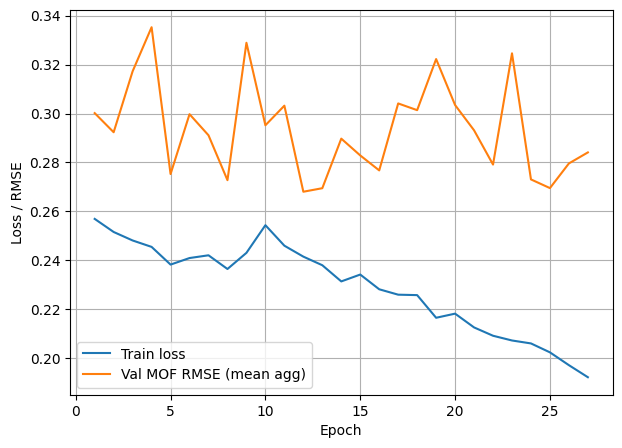

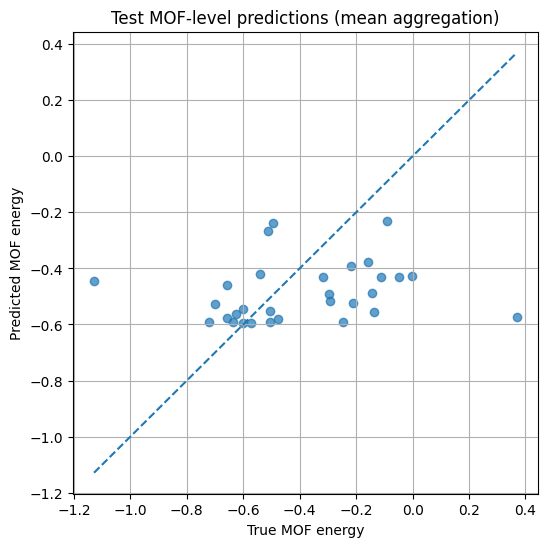

In [27]:
# =========================
# 15) OPTIONAL PLOTS
# =========================

import matplotlib.pyplot as plt

# Training curves
plt.figure(figsize=(7,5))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train loss")
plt.plot(hist_df["epoch"], hist_df["val_mean_RMSE"], label="Val MOF RMSE (mean agg)")
plt.xlabel("Epoch")
plt.ylabel("Loss / RMSE")
plt.legend()
plt.grid(True)
plt.show()

# Predicted vs true on test MOF-level mean agg
plt.figure(figsize=(6,6))
plt.scatter(test_mof_mean_df["y_true"], test_mof_mean_df["y_pred"], alpha=0.7)
mn = min(test_mof_mean_df["y_true"].min(), test_mof_mean_df["y_pred"].min())
mx = max(test_mof_mean_df["y_true"].max(), test_mof_mean_df["y_pred"].max())
plt.plot([mn, mx], [mn, mx], '--')
plt.xlabel("True MOF energy")
plt.ylabel("Predicted MOF energy")
plt.title("Test MOF-level predictions (mean aggregation)")
plt.grid(True)
plt.show()

Uncertainty quantification - Ensemble/Bootstrapping and Interpretability - Atom Level something

Come back and check Early stopping Tab - MSE Loss and Mean predictions. possibly aggregation